# Жесткие сестемы ОДУ

## ФДН

Для нахождения $y_{n+1}$ на каждом шаге решается нелинейное уравнение методом Ньютона:$$F(y_{n+1}) = \frac{25}{12} y_{n+1} - h f(t_{n+1}, y_{n+1}) - \text{history\_terms} = 0$$

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Параметры задачи
w = 1
A = [0.5, (1 + np.sqrt(1 + 1 / (64 * w**2))) / 2]
a = [1e3, 1e6]
T_START = 0
T_k = 200
Y0 = np.array([2.0, 0.0])

alpha = [
    [3 / 2, -2, 1 / 2, 0, 0],
    [11 / 6, -3, 3 / 2, -1 / 3, 0],
    [25 / 12, -4, 3, -4 / 3, 1 / 4],
]

GAMMA = np.array([(2 + np.sqrt(2)) / 2, (3 + np.sqrt(3)) / 6])
C1 = GAMMA
C2 = np.array([(2 - np.sqrt(2)) / 2, (3 - np.sqrt(3)) / 6])
A21 = np.array([-np.sqrt(2), (3 - 2 * np.sqrt(3)) / 6])
B = 0.5


def f(t, y, a_index, A_index):
    """Правая часть системы Ван-дер-Поля"""
    f1 = a[a_index] * (y[1] - (y[0] ** 3 / 3 - y[0]))
    f2 = -y[0] + A[A_index] * np.cos(w * t)
    return np.array([f1, f2])


def jacobian(t, y, a_index):
    """Якобиан системы для метода Ньютона"""
    df1dy1 = a[a_index] * (1 - y[0] ** 2)
    df1dy2 = a[a_index]
    df2dy1 = -1.0
    df2dy2 = 0.0
    return np.array([[df1dy1, df1dy2], [df2dy1, df2dy2]])


def solve_sdirk_step(t_n, y_n, h, A_index, a_index, table_index):
    """Один шаг метода SDIRK-2 с использованием ручного метода Ньютона"""

    # Стадия 1
    def stage1(k1):
        return k1 - f(
            t_n + C1[table_index] * h,
            y_n + h * GAMMA[table_index] * k1,
            a_index,
            A_index,
        )

    k1_guess = f(t_n, y_n, a_index, A_index)
    k1 = fsolve(
        stage1,
        k1_guess,
        fprime=lambda k: np.eye(2)
        - h
        * GAMMA[table_index]
        * jacobian(
            t_n + C1[table_index] * h, y_n + h * GAMMA[table_index] * k, a_index
        ),
    )

    # Стадия 2

    def stage2(k2):
        return k2 - f(
            t_n + C2[table_index] * h,
            y_n + h * A21[table_index] * k1 + h * GAMMA[table_index] * k2,
            a_index,
            A_index,
        )

    k2 = fsolve(
        stage2,
        k1,
        fprime=lambda k: np.eye(2)
        - h
        * GAMMA[table_index]
        * jacobian(
            t_n + C2[table_index] * h,
            y_n + h * A21[table_index] * k1 + h * GAMMA[table_index] * k,
            a_index,
        ),
    )

    return y_n + h * (B * k1 + B * k2)

In [12]:
def solve_bdf(a_index, A_index, fdn_index, h):
    # Уменьшаем шаг для стабильности при a = 1e6
    t_vals = [T_START]
    y_vals = [Y0]

    print(f"Запуск разгона SDIRK (h={h})...")
    for i in range(fdn_index + 1):
        y_next = solve_sdirk_step(t_vals[-1], y_vals[-1], h, a_index, A_index, 1)
        t_vals.append(t_vals[-1] + h)
        y_vals.append(y_next)

    print("Запуск основного метода ФДН...")
    steps = int((T_k - T_START) / h)

    for n in range(fdn_index + 1, steps):
        t_next = t_vals[-1] + h
        # Предсказание (начальное приближение)
        y_curr = y_vals[-1].copy()

        # Свободный член: 4y_n - 3y_{n-1} + 4/3y_{n-2} - 1/4y_{n-3}
        history = 0
        for i in range(fdn_index + 2):
            history += -alpha[fdn_index][i + 1] * y_vals[-(i + 1)]

        # Ручной метод Ньютона (более стабилен для жестких систем)
        for _ in range(10):  # Обычно сходится за 3-5 итераций
            res = (
                alpha[fdn_index][0] * y_curr
                - history
                - h * f(t_next, y_curr, a_index, A_index)
            )
            jac = alpha[fdn_index][0] * np.eye(2) - h * jacobian(
                t_next, y_curr, a_index
            )

            delta = np.linalg.solve(jac, -res)
            y_curr += delta

            if np.linalg.norm(delta) < 1e-9:
                break

        t_vals.append(t_next)
        y_vals.append(y_curr)

        if (n + 1) % 50000 == 0:
            print(f"Time: {t_next:.2f} / {T_k}")

    return np.array(t_vals), np.array(y_vals)

## Однократно диагонально неявеый метод Рунге-Кутты с двумя стадиями

In [16]:
def solve_sdirk_full(a_index, A_index, table_index, h):
    """Основной цикл решения"""
    t_vals = [T_START]
    y_vals = [Y0]
    steps = int((T_k - T_START) / h)

    print(f"Запуск расчета SDIRK-2 (шаг h={h})...")

    for n in range(steps):
        t_next = t_vals[-1] + h
        # Теперь мы просто элегантно вызываем нашу функцию!
        y_next = solve_sdirk_step(
            t_vals[-1], y_vals[-1], h, a_index, A_index, table_index
        )

        t_vals.append(t_next)
        y_vals.append(y_next)

        if (n + 1) % 50000 == 0:
            print(f"Time: {t_next:.2f} / {T_k}")

    return np.array(t_vals), np.array(y_vals)

Запуск расчета SDIRK-2 (шаг h=0.001)...


/tmp/ipykernel_77756/4150504634.py:55: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  k1 = fsolve(
/tmp/ipykernel_77756/4150504634.py:55: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  k1 = fsolve(
/tmp/ipykernel_77756/4150504634.py:76: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  k2 = fsolve(
/tmp/ipykernel_77756/4150504634.py:76: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  k2 = fsolve(


Time: 50.00 / 200
Time: 100.00 / 200
Time: 150.00 / 200
Time: 200.00 / 200


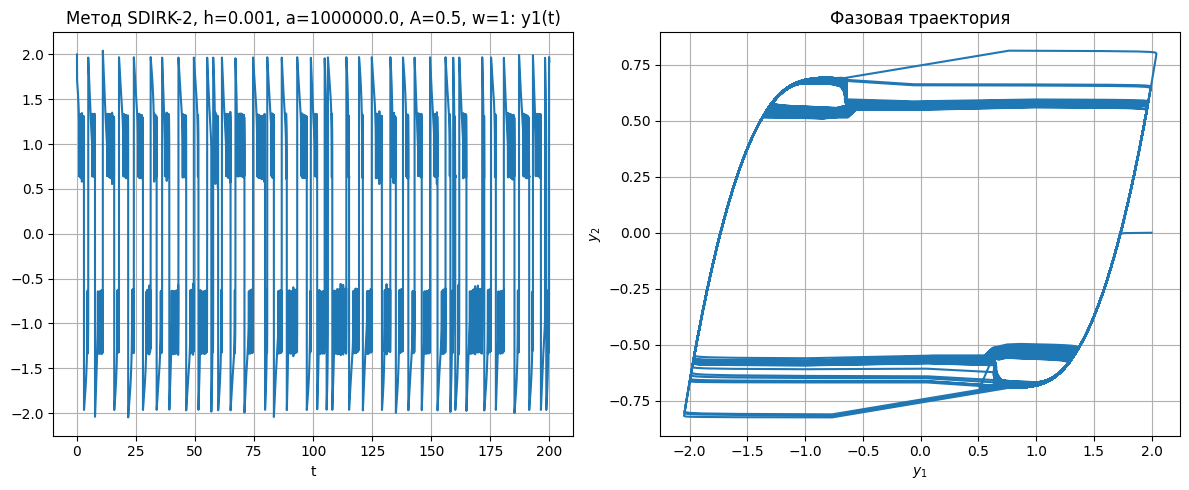

In [21]:
def draw_bdf(a_index, A_index, fdn_index, h):
    t, y = solve_bdf(a_index, A_index, fdn_index, h)
    # Визуализация
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(t, y[:, 0], label="$y_1(t)$")
    plt.title(
        f"Метод ФДН-{fdn_index+2}, h={h}, a={a[a_index]}, A={A[A_index]}, w={w}: y1(t)"
    )
    plt.xlabel("t")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(y[:, 0], y[:, 1])
    plt.title("Фазовая траектория")
    plt.xlabel("$y_1$")
    plt.ylabel("$y_2$")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def draw_sdirk(a_index, A_index, table_index, h):
    t, y = solve_sdirk_full(a_index, A_index, table_index, h)
    # Визуализация
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(t, y[:, 0], label="$y_1(t)$")
    plt.title(
        f"Метод SDIRK-{table_index+2}, h={h}, a={a[a_index]}, A={A[A_index]}, w={w}: y1(t)"
    )
    plt.xlabel("t")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(y[:, 0], y[:, 1])
    plt.title("Фазовая траектория")
    plt.xlabel("$y_1$")
    plt.ylabel("$y_2$")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


#draw_bdf(0, 0, 0, 0.001)
draw_sdirk(1, 0, 0, 0.001)

## Функции устойчивости
### 1. Тестовое уравнение Дальквиста


Для анализа устойчивости численных методов применяется линейное тестовое уравнение $y' = \lambda y$, где $\lambda \in \mathbb{C}$. Область устойчивости определяется как множество значений $z = \lambda h$ (где $h$ — шаг интегрирования), при которых численное решение $y_n \to 0$ при $n \to \infty$.

### 2. Функция устойчивости ФДН-4 (BDF-4)


Многошаговые методы задаются характеристическими многочленами $\rho(\zeta)$ и $\sigma(\zeta)$. Для ФДН-4 они имеют вид:

$$\rho(\zeta) = \frac{25}{12}\zeta^4 - 4\zeta^3 + 3\zeta^2 - \frac{4}{3}\zeta + \frac{1}{4}$$

$$\sigma(\zeta) = \zeta^4$$

Граница области абсолютной устойчивости находится путем подстановки $\zeta = e^{i\theta}$ (где $\theta \in [0, 2\pi]$) в уравнение $z(\theta) = \frac{\rho(\zeta)}{\sigma(\zeta)}$:

$$z(\theta) = \frac{25}{12} - 4e^{-i\theta} + 3e^{-2i\theta} - \frac{4}{3}e^{-3i\theta} + \frac{1}{4}e^{-4i\theta}$$

Область устойчивости ФДН-4 находится снаружи замкнутой кривой $z(\theta)$. Метод не является абсолютно A-устойчивым (кривая немного заходит в левую полуплоскость), но он $A(\alpha)$-устойчив, что достаточно для нашей задачи.

### 3. Функция устойчивости SDIRK-2


Для методов Рунге-Кутты с матрицей Бутчера $A$ и весами $b^T$ функция устойчивости задается рациональной дробью:$$R(z) = \frac{\det(I - z A + z \mathbf{1} b^T)}{\det(I - z A)}$$Для используемой 2-стадийной схемы знаменатель равен $\det(I - z A) = (1 - \gamma z)^2$.После раскрытия определителей числителя для заданных коэффициентов $\gamma = \frac{3+\sqrt{3}}{6}$ и $a_{21} = \frac{3-2\sqrt{3}}{6}$, функция устойчивости принимает вид:$$R(z) = \frac{1 + c_1 z + c_2 z^2}{(1 - \gamma z)^2}$$Где $c_1 = 1 - 2\gamma$ и $c_2 = \gamma^2 - \gamma + \frac{1}{2} a_{21}$.Область устойчивости определяется условием $|R(z)| \le 1$. Поскольку метод является L-устойчивым, его область полностью включает левую комплексную полуплоскость (и даже часть правой).

<>:107: SyntaxWarning: invalid escape sequence '\l'
<>:107: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_77756/1234157603.py:107: SyntaxWarning: invalid escape sequence '\l'
  "Устойчиво\n|R(z)| $\leq$ 1\n(Вся левая полуплоскость)",


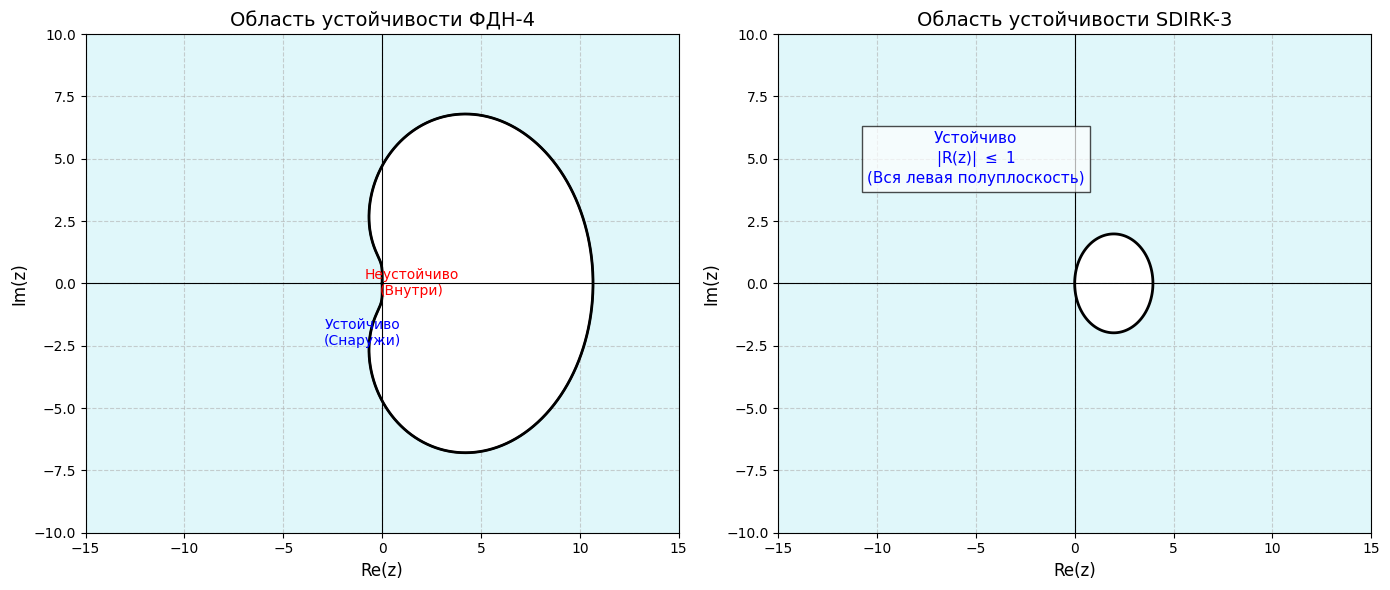

In [15]:
# ==========================================
# 1. Построение для ФДН-4 (BDF)
# ==========================================
theta = np.linspace(0, 2 * np.pi, 2000)

# Характеристическое уравнение ФДН
z_bdf = [
    row[0]
    + row[1] * np.exp(-1j * theta)
    + row[2] * np.exp(-2j * theta)
    + row[3] * np.exp(-3j * theta)
    + row[4] * np.exp(-4j * theta)
    for row in alpha
]
# ==========================================
# 2. Построение для SDIRK
# ==========================================

# Коэффициенты числителя функции R(z)
c1_coef = 1 - 2 * GAMMA
c2_coef = GAMMA**2 - GAMMA + 0.5 * A21

# Создаем сетку на комплексной плоскости
x = np.linspace(-15, 15, 600)
y = np.linspace(-10, 10, 600)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# Функция устойчивости R(z)
R_sd = [
    (1 + c1_c * Z + c2_c * Z**2) / (1 - GAM * Z) ** 2
    for c1_c, c2_c, GAM in zip(c1_coef, c2_coef, GAMMA)
]

# ==========================================
# Визуализация
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


# --- График ФДН-4 ---
# Красим весь фон как "Устойчивую зону"
def bdf_graph(ax, bdf_index):
    ax.set_facecolor("#e0f7fa")
    # Красим область внутри кривой как "Неустойчивую"
    ax.fill(
        z_bdf[bdf_index].real,
        z_bdf[bdf_index].imag,
        color="white",
        edgecolor="black",
        linewidth=1.5,
        zorder=2,
    )
    ax.plot(z_bdf[bdf_index].real, z_bdf[bdf_index].imag, "k-", linewidth=2)

    ax.axhline(0, color="black", linewidth=0.8, zorder=3)
    ax.axvline(0, color="black", linewidth=0.8, zorder=3)
    ax.set_title(f"Область устойчивости ФДН-{bdf_index+2}", fontsize=14)
    ax.set_xlabel("Re(z)", fontsize=12)
    ax.set_ylabel("Im(z)", fontsize=12)
    ax.set_xlim(-15, 15)
    ax.set_ylim(-10, 10)
    ax.grid(True, linestyle="--", alpha=0.6, zorder=1)

    ax.text(
        1.5,
        0,
        "Неустойчиво\n(Внутри)",
        ha="center",
        va="center",
        fontsize=10,
        color="red",
        zorder=4,
    )
    ax.text(
        -1,
        -2,
        "Устойчиво\n(Снаружи)",
        ha="center",
        va="center",
        fontsize=10,
        color="blue",
    )
    return ax


# --- График SDIRK ---
# Рисуем контуры |R(z)| <= 1
def sdirk_graph(ax, table_index):
    contour = ax.contourf(
        X, Y, np.abs(R_sd[table_index]), levels=[0, 1], colors=["#e0f7fa"]
    )
    ax.contour(
        X, Y, np.abs(R_sd[table_index]), levels=[1], colors="black", linewidths=2
    )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Область устойчивости SDIRK-{table_index+2}", fontsize=14)
    ax.set_xlabel("Re(z)", fontsize=12)
    ax.set_ylabel("Im(z)", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.6)

    ax.text(
        -5,
        5,
        "Устойчиво\n|R(z)| $\leq$ 1\n(Вся левая полуплоскость)",
        ha="center",
        va="center",
        fontsize=11,
        color="blue",
        bbox=dict(facecolor="white", alpha=0.7),
    )
    return ax


ax1 = bdf_graph(ax1, 2)
ax2 = sdirk_graph(ax2, 1)
plt.tight_layout()
plt.show()